In [ ]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt

# 🧹 Étape 2 : Préparation & Nettoyage de Données (Data Wrangling) (Squelette Étudiant)

Cette étape correspond au deuxième chapitre du projet. L'objectif est d'effectuer un audit de qualité des données brutes du dataset **Automobile**, puis de mettre en œuvre un nettoyage rigoureux : traitement des valeurs manquantes, encodage des variables catégorielles et détection des valeurs aberrantes.

### 1. Initialisation et imports

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Ajout du dossier parent au chemin de recherche des modules
sys.path.append(os.path.abspath('..'))

print("Librairies prêtes pour le Wrangling !")

Librairies prêtes pour le Wrangling !


### 2. Chargement du dataset brut et Audit Initial

Chargement du dataset **Automobile** et inspection de la qualité des données : dimensions, types, valeurs manquantes, doublons et statistiques descriptives.

In [2]:
raw_data_path = '../data/raw/Automobile.csv'
df_raw = pd.read_csv(raw_data_path)

print("=== Dimensions ===")
print(f"Shape : {df_raw.shape}")

print("\n=== Types des colonnes ===")
print(df_raw.dtypes)

print("\n=== Valeurs manquantes par colonne ===")
print(df_raw.isnull().sum())

print("\n=== Nombre de doublons ===")
print(df_raw.duplicated().sum())

print("\n=== Statistiques descriptives ===")
df_raw.describe()

=== Dimensions ===
Shape : (398, 9)

=== Types des colonnes ===
name                str
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
dtype: object

=== Valeurs manquantes par colonne ===
name            0
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

=== Nombre de doublons ===
0

=== Statistiques descriptives ===


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


### 3. Uniformisation des Formats de Dates

Le dataset Automobile ne contient pas de colonne de dates. Cette section est consacrée au traitement de la seule valeur manquante identifiée lors de l'audit : la colonne **horsepower** (6 valeurs NaN). On impute ces valeurs par la médiane de la distribution.

In [3]:
# Affichage des 6 lignes où horsepower est NaN
print("=== Lignes avec horsepower manquant ===")
print(df_raw[df_raw['horsepower'].isnull()])

# Calcul et affichage de la médiane
hp_median = df_raw['horsepower'].median()
print(f"\nMédiane de horsepower : {hp_median}")

# Imputation par la médiane
df_raw['horsepower'] = df_raw['horsepower'].fillna(hp_median)

# Vérification : aucune valeur manquante restante
print("\n=== Valeurs manquantes après imputation ===")
print(df_raw.isnull().sum())

=== Lignes avec horsepower manquant ===
                     name   mpg  cylinders  displacement  horsepower  weight  \
32             ford pinto  25.0          4          98.0         NaN    2046   
126         ford maverick  21.0          6         200.0         NaN    2875   
330  renault lecar deluxe  40.9          4          85.0         NaN    1835   
336    ford mustang cobra  23.6          4         140.0         NaN    2905   
354           renault 18i  34.5          4         100.0         NaN    2320   
374        amc concord dl  23.0          4         151.0         NaN    3035   

     acceleration  model_year  origin  
32           19.0          71     usa  
126          17.0          74     usa  
330          17.3          80  europe  
336          14.3          80     usa  
354          15.8          81  europe  
374          20.5          82     usa  

Médiane de horsepower : 93.5

=== Valeurs manquantes après imputation ===
name            0
mpg             0
cylinder

### 4. Identification et Filtrage des Valeurs Aberrantes (Outliers)

Suppression de la colonne `name` (305 valeurs uniques, purement nominale), encodage de la variable catégorielle `origin` avec `LabelEncoder`, puis détection des outliers par la méthode IQR sur les 6 colonnes numériques.

In [4]:
# Suppression de la colonne 'name' (identifiant nominal sans valeur prédictive)
df_clean = df_raw.drop(columns=['name'])
print(f"Shape après suppression de 'name' : {df_clean.shape}")

# Encodage de la variable catégorielle 'origin' avec LabelEncoder
le = LabelEncoder()
df_clean['origin'] = le.fit_transform(df_clean['origin'])

print("\n=== Mapping d'encodage de 'origin' ===")
for label, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {label} → {code}")

Shape après suppression de 'name' : (398, 8)

=== Mapping d'encodage de 'origin' ===
  europe → 0
  japan → 1
  usa → 2


=== Nombre d'outliers détectés (méthode IQR) ===
  mpg : 1 outlier(s)
  cylinders : 0 outlier(s)
  displacement : 0 outlier(s)
  horsepower : 11 outlier(s)
  weight : 0 outlier(s)
  acceleration : 7 outlier(s)


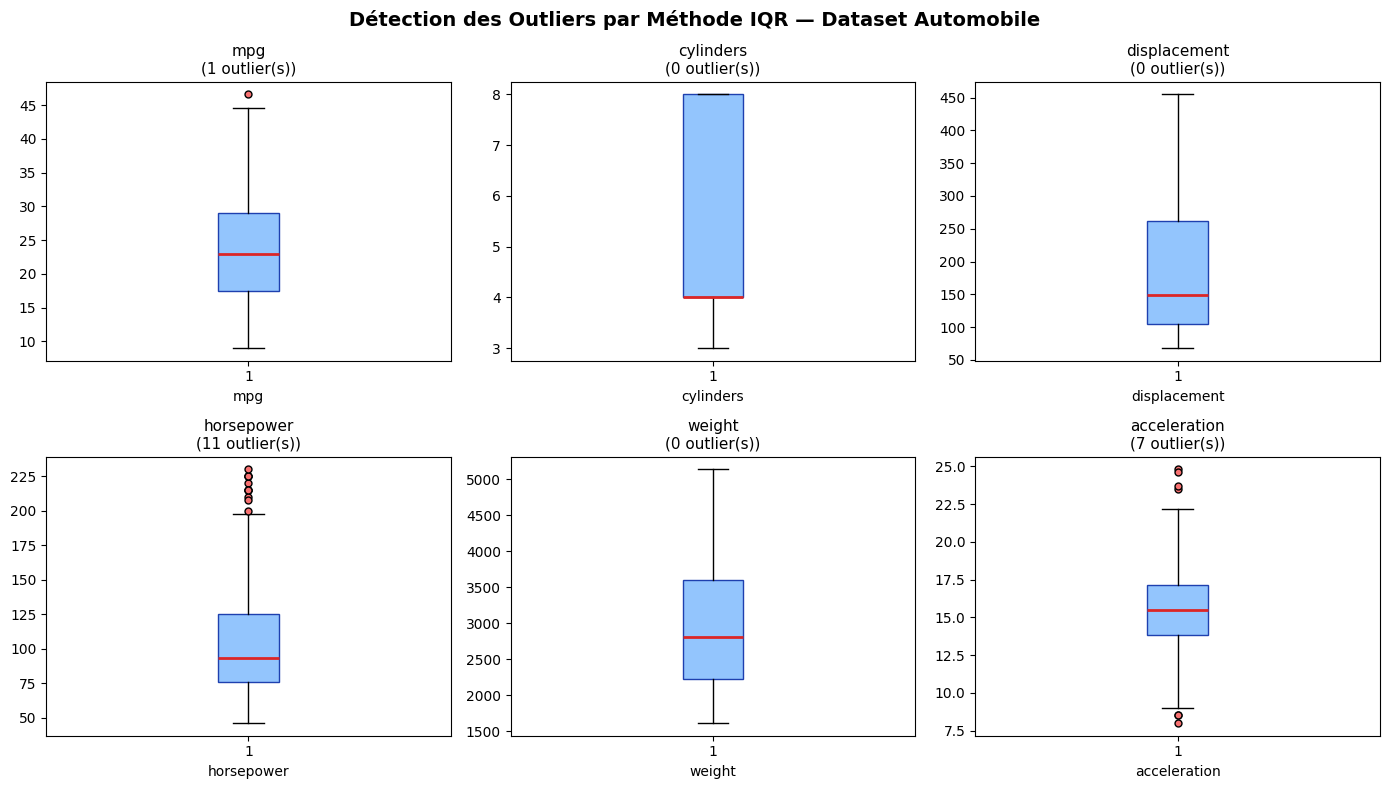


=== Statistiques descriptives après encodage ===


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.304020,2970.424623,15.568090,76.010050,1.449749
std,7.815984,1.701004,104.269838,38.222625,846.841774,2.757689,3.697627,0.775076
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,0.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,2.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,2.000000


In [5]:
# Détection des outliers par méthode IQR sur les colonnes numériques
numeric_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']

outlier_counts = {}
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_counts[col] = n_outliers

print("=== Nombre d'outliers détectés (méthode IQR) ===")
for col, count in outlier_counts.items():
    print(f"  {col} : {count} outlier(s)")

# Visualisation : boxplots 2x3
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Détection des Outliers par Méthode IQR — Dataset Automobile", fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), numeric_cols):
    ax.boxplot(df_clean[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#93c5fd', color='#1e40af'),
               medianprops=dict(color='#dc2626', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='#f87171', markersize=5))
    ax.set_title(f"{col}\n({outlier_counts[col]} outlier(s))", fontsize=11)
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

print("\n=== Statistiques descriptives après encodage ===")
df_clean.describe()

### 5. Imputation des valeurs manquantes

Validation finale de l'absence de valeurs manquantes et confirmation des dimensions du dataset nettoyé.

In [6]:
print("=== Valeurs manquantes restantes ===")
print(df_clean.isnull().sum())

print(f"\nDimensions finales du dataset nettoyé : {df_clean.shape}")

=== Valeurs manquantes restantes ===
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

Dimensions finales du dataset nettoyé : (398, 8)


### 6. Sauvegarde des données propres

Enregistrement du dataset nettoyé dans le répertoire `data/processed/`.

In [7]:
processed_path = '../data/processed/cleaned_data_sample.csv'
os.makedirs(os.path.dirname(processed_path), exist_ok=True)
df_clean.to_csv(processed_path, index=False)

print(f"Données propres sauvegardées dans : {processed_path}")
print(f"Shape finale : {df_clean.shape}")
print("Wrangling terminé avec succès !")

Données propres sauvegardées dans : ../data/processed/cleaned_data_sample.csv
Shape finale : (398, 8)
Wrangling terminé avec succès !
